In [3]:
import pyxdf

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt

In [4]:
file_path=r"C:\Users\abolhassni\Desktop\TU Darmstadt\Term3\ANSYMB\LSL\imu_motion_capture_analysis\data\raw\TEST 27 MAI\standing.xdf"

streams, header=pyxdf.load_xdf(file_path)



In [5]:
print(len(streams))
print(len(header))

4
1


In [6]:
names=[]
for i in enumerate(streams):
    sensor_name=streams[0]["info"]["name"]
    names.append(sensor_name)


names


[['Xsens_MTw2_00B4D0C5'],
 ['Xsens_MTw2_00B4D0C5'],
 ['Xsens_MTw2_00B4D0C5'],
 ['Xsens_MTw2_00B4D0C5']]

In [7]:
for i, stream in enumerate(streams):
    name = stream["info"]["name"][0]
    
    data = stream["time_series"]
    time = stream["time_stamps"]
    
    print("Index:", i)
    print("Name:", name)
    print("Data shape:", data.shape)
    print("Time shape:", time.shape)
    
    if len(time) == 0:
        print("Status: EMPTY time_stamps")
    else:
        duration = time[-1] - time[0]
        fs_estimated = data.shape[0] / duration
        
        print("Duration:", duration)
        print("Estimated sampling rate:", fs_estimated)
    
    print("----------------------------")

Index: 0
Name: Xsens_MTw2_00B4D0C5
Data shape: (3479, 15)
Time shape: (3479,)
Duration: 35.023987164138816
Estimated sampling rate: 99.3319231101752
----------------------------
Index: 1
Name: Xsens_MTw2_00B4D0BE
Data shape: (3484, 15)
Time shape: (3484,)
Duration: 35.07007867383072
Estimated sampling rate: 99.34394594329095
----------------------------
Index: 2
Name: Xsens_MTw2_00B4D0C8
Data shape: (3478, 15)
Time shape: (3478,)
Duration: 35.044734129623976
Estimated sampling rate: 99.24458228547327
----------------------------
Index: 3
Name: Xsens_MTw2_00B4D0D0
Data shape: (3485, 15)
Time shape: (3485,)
Duration: 35.04807441245066
Estimated sampling rate: 99.43484937255128
----------------------------


Die Daten jedes Sensors wurden in einem separaten DataFrame gespeichert und über den Sensornamen im Dictionary sensor_dfs organisiert.

In [8]:
sensor_dfs = {}

for stream in streams:
    sensor_name = stream["info"]["name"][0]
    
    data = stream["time_series"]
    time = stream["time_stamps"]
    
    time_insert = time - time[0]
    
    channels = stream["info"]["desc"][0]["channels"][0]["channel"]
    column_names = [ch["label"][0] for ch in channels]
    
    df = pd.DataFrame(data, columns=column_names)
    
    df.insert(0, "time_stamp", time)
    df.insert(1, "time_insert", time_insert)
    
    sensor_dfs[sensor_name] = df

In [9]:
sensor_dfs.keys()

dict_keys(['Xsens_MTw2_00B4D0C5', 'Xsens_MTw2_00B4D0BE', 'Xsens_MTw2_00B4D0C8', 'Xsens_MTw2_00B4D0D0'])

In [10]:
sensor_dfs['Xsens_MTw2_00B4D0C8']

,time_stamp,time_insert,qw,qx,qy,qz,ax,ay,az,gx,gy,gz,mx,my,mz,packet_counter,sample_time_fine
0,516974.899923,0.000000,0.599287,-0.239032,0.736809,0.202066,-9.600438,0.108267,-2.031567,0.003704,-0.013808,-0.010046,0.729492,-0.307373,0.464844,42246.0,0.0
1,516974.910002,0.010079,0.599333,-0.239051,0.736756,0.202101,-9.648154,0.054096,-2.101200,-0.007063,-0.012252,-0.005640,0.720947,-0.310791,0.464600,42247.0,0.0
2,516974.920081,0.020158,0.599369,-0.239128,0.736681,0.202178,-9.650875,0.101896,-2.050581,-0.009158,-0.014520,-0.007569,0.727051,-0.307617,0.470215,42248.0,0.0
3,516974.930160,0.030237,0.599414,-0.239160,0.736618,0.202234,-9.649954,0.077359,-2.073876,-0.012388,-0.013624,-0.005436,0.729004,-0.309814,0.467041,42249.0,0.0
4,516974.940239,0.040316,0.599445,-0.239253,0.736541,0.202314,-9.601788,0.082219,-2.075375,-0.012508,-0.013613,-0.009531,0.726807,-0.308350,0.470703,42250.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3473,517009.904341,35.004418,0.595652,-0.267165,0.724018,0.222754,-9.627712,0.045418,-2.158644,0.003331,-0.000735,-0.000080,0.728027,-0.299072,0.469727,45747.0,0.0
3474,517009.914420,35.014497,0.595668,-0.267147,0.724015,0.222745,-9.605041,0.050528,-2.184001,0.004470,-0.001686,-0.002061,0.737061,-0.301514,0.462891,45748.0,0.0
3475,517009.924499,35.024576,0.595665,-0.267140,0.724024,0.222730,-9.581200,0.055316,-2.185030,0.004244,0.000461,-0.002086,0.734375,-0.311035,0.466309,45749.0,0.0
3476,517009.934578,35.034655,0.595670,-0.267124,0.724031,0.222714,-9.594899,0.002172,-2.184947,0.005203,0.001647,-0.002130,0.728271,-0.307373,0.468994,45750.0,0.0


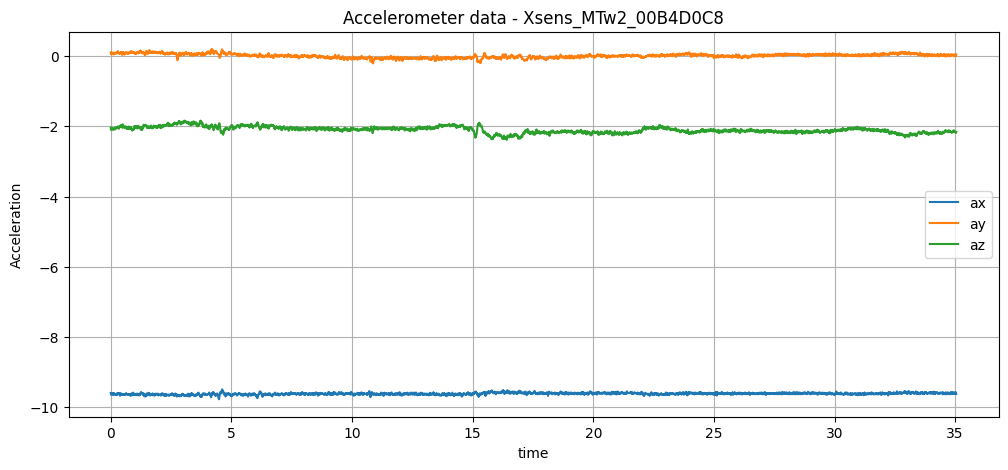

In [11]:
df = sensor_dfs['Xsens_MTw2_00B4D0C8']
    
t = df["time_insert"]
    
plt.figure(figsize=(12, 5))

plt.plot(t, df["ax"], label="ax")
plt.plot(t, df["ay"], label="ay")
plt.plot(t, df["az"], label="az")

plt.xlabel("time")
plt.ylabel("Acceleration")
plt.title("Accelerometer data - Xsens_MTw2_00B4D0C8")
plt.legend()
plt.grid(True)
plt.show()

Für die Standing Calibration wurde aus den Beschleunigungsachsen ax, ay und az der Mittelwert berechnet. Dieser Mittelwert beschreibt die Richtung der Gravitation im Sensorkoordinatensystem während der statischen Standphase.

Für den Sensor Xsens_MTw2_00B4D0C8 wurde während der statischen Standphase der mittlere Beschleunigungsvektor berechnet:

acc_static = [-9.6214, 0.0124, -2.1004]

Der größte Anteil der Beschleunigung liegt auf der negativen x-Achse des Sensors. Ein kleinerer Anteil liegt auf der negativen z-Achse, während die y-Achse nahezu keinen Beitrag zeigt. Daraus lässt sich ableiten, dass die Gravitationsrichtung im Sensorkoordinatensystem hauptsächlich entlang der negativen x-Achse verläuft.


<p align="center">
  <img src="Xsens_MTw2_00B4D0C8.png" alt="Xsens_MTw2_00B4D0C8" width="500">
</p>

In [12]:
acc_static = sensor_dfs["Xsens_MTw2_00B4D0C8"][["ax", "ay", "az"]].mean().values

print("acc_static:", acc_static)


acc_static: [-9.6214075   0.01235573 -2.1003745 ]


Der normalisierte Gravitationsvektor zeigt, dass die Gravitation hauptsächlich entlang der negativen x-Achse des Sensors verläuft.

In [13]:

g_sensor = acc_static / np.linalg.norm(acc_static)

print("g_sensor:", g_sensor)

g_sensor: [-0.97699046  0.00125464 -0.21327917]


In [14]:
gravity_vectors = {}

for sensor_name, df_sensor in sensor_dfs.items():
    acc_static = df_sensor[["ax", "ay", "az"]].mean().values
    g_sensor = acc_static / np.linalg.norm(acc_static)
    
    gravity_vectors[sensor_name] = g_sensor

gravity_vectors

{'Xsens_MTw2_00B4D0C5': array([-0.9822346 ,  0.00794906,  0.18748905], dtype=float32),
 'Xsens_MTw2_00B4D0BE': array([-0.9977788 , -0.0434721 , -0.05047445], dtype=float32),
 'Xsens_MTw2_00B4D0C8': array([-0.97699046,  0.00125464, -0.21327917], dtype=float32),
 'Xsens_MTw2_00B4D0D0': array([-0.2089611 ,  0.05583238,  0.97632885], dtype=float32)}

* Für den Sensor `Xsens_MTw2_00B4D0C5` liegt die Gravitation hauptsächlich auf der negativen `x-Achse` des Sensors. Zusätzlich gibt es einen kleineren Anteil auf der positiven z-Achse.

* Für den Sensor `Xsens_MTw2_00B4D0BE` liegt die Gravitation fast vollständig auf der negativen `x-Achse`. Die y- und z-Anteile sind sehr klein.

* Für den Sensor `Xsens_MTw2_00B4D0C8` liegt die Gravitation ebenfalls hauptsächlich auf der negativen `x-Achse`. Zusätzlich ist ein kleiner Anteil auf der negativen z-Achse vorhanden.

* Für den Sensor `Xsens_MTw2_00B4D0D0` liegt die Gravitation hauptsächlich auf der positiven `z-Achse`. Zusätzlich gibt es einen kleineren Anteil auf der negativen x-Achse.


In [15]:
for sensor_name, g in gravity_vectors.items():
    print(sensor_name, g)

Xsens_MTw2_00B4D0C5 [-0.9822346   0.00794906  0.18748905]
Xsens_MTw2_00B4D0BE [-0.9977788  -0.0434721  -0.05047445]
Xsens_MTw2_00B4D0C8 [-0.97699046  0.00125464 -0.21327917]
Xsens_MTw2_00B4D0D0 [-0.2089611   0.05583238  0.97632885]


In [5]:
SENSOR_NAME_MAP = {
    "Xsens_MTw2_00B4D0C5": "Pelv",
    "Xsens_MTw2_00B4D0BE": "lLeg_L",
    "Xsens_MTw2_00B4D0C8": "uLeg_L",
    "Xsens_MTw2_00B4D0D0": "Foot_L",
}

In [17]:
sensor_dfs_mapped = {}

for old_name, df in sensor_dfs.items():
    new_name = SENSOR_NAME_MAP.get(old_name, old_name)
    sensor_dfs_mapped[new_name] = df

In [8]:
for sensor_name, g in gravity_vectors.items():
    print(sensor_name, g)

Pelv [-0.9822346   0.00794906  0.18748905]
lLeg_L [-0.9977788  -0.0434721  -0.05047445]
uLeg_L [-0.97699046  0.00125464 -0.21327917]
Foot_L [-0.2089611   0.05583238  0.97632885]


In [20]:
sensor_dfs_mapped["uLeg_L"]


,time_stamp,time_insert,qw,qx,qy,qz,ax,ay,az,gx,gy,gz,mx,my,mz,packet_counter,sample_time_fine
0,516974.899923,0.000000,0.599287,-0.239032,0.736809,0.202066,-9.600438,0.108267,-2.031567,0.003704,-0.013808,-0.010046,0.729492,-0.307373,0.464844,42246.0,0.0
1,516974.910002,0.010079,0.599333,-0.239051,0.736756,0.202101,-9.648154,0.054096,-2.101200,-0.007063,-0.012252,-0.005640,0.720947,-0.310791,0.464600,42247.0,0.0
2,516974.920081,0.020158,0.599369,-0.239128,0.736681,0.202178,-9.650875,0.101896,-2.050581,-0.009158,-0.014520,-0.007569,0.727051,-0.307617,0.470215,42248.0,0.0
3,516974.930160,0.030237,0.599414,-0.239160,0.736618,0.202234,-9.649954,0.077359,-2.073876,-0.012388,-0.013624,-0.005436,0.729004,-0.309814,0.467041,42249.0,0.0
4,516974.940239,0.040316,0.599445,-0.239253,0.736541,0.202314,-9.601788,0.082219,-2.075375,-0.012508,-0.013613,-0.009531,0.726807,-0.308350,0.470703,42250.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3473,517009.904341,35.004418,0.595652,-0.267165,0.724018,0.222754,-9.627712,0.045418,-2.158644,0.003331,-0.000735,-0.000080,0.728027,-0.299072,0.469727,45747.0,0.0
3474,517009.914420,35.014497,0.595668,-0.267147,0.724015,0.222745,-9.605041,0.050528,-2.184001,0.004470,-0.001686,-0.002061,0.737061,-0.301514,0.462891,45748.0,0.0
3475,517009.924499,35.024576,0.595665,-0.267140,0.724024,0.222730,-9.581200,0.055316,-2.185030,0.004244,0.000461,-0.002086,0.734375,-0.311035,0.466309,45749.0,0.0
3476,517009.934578,35.034655,0.595670,-0.267124,0.724031,0.222714,-9.594899,0.002172,-2.184947,0.005203,0.001647,-0.002130,0.728271,-0.307373,0.468994,45750.0,0.0


In [7]:


gravity_vectors = {
    "Pelv": np.array([-0.9822346,   0.00794906,  0.18748905]),
    "lLeg_L": np.array([-0.9977788,  -0.0434721,  -0.05047445]),
    "uLeg_L": np.array([-0.97699046,  0.00125464, -0.21327917]),
    "Foot_L": np.array([-0.2089611,   0.05583238,  0.97632885]),
}

axes = {
    "+X": np.array([1, 0, 0]),
    "-X": np.array([-1, 0, 0]),
    "+Y": np.array([0, 1, 0]),
    "-Y": np.array([0, -1, 0]),
    "+Z": np.array([0, 0, 1]),
    "-Z": np.array([0, 0, -1]),
}

for sensor, g in gravity_vectors.items():
    g = g / np.linalg.norm(g)

    best_axis = None
    best_angle = 999

    for axis_name, axis_vec in axes.items():
        angle = np.degrees(np.arccos(np.clip(np.dot(g, axis_vec), -1, 1)))

        if angle < best_angle:
            best_angle = angle
            best_axis = axis_name

    print(sensor, "nearest axis:", best_axis, "angle:", round(best_angle, 2), "deg")

Pelv nearest axis: -X angle: 10.82 deg
lLeg_L nearest axis: -X angle: 3.82 deg
uLeg_L nearest axis: -X angle: 12.31 deg
Foot_L nearest axis: +Z angle: 12.49 deg
